In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# ==============================
# 1 โหลดข้อมูลทอง
# ==============================

symbol = "GC=F"

data = yf.download(
    symbol,
    period="60d", # Use period='60d' to get recent 5m data
    interval="5m"
)

data = data.dropna()

# Flatten MultiIndex columns if they exist (common with yfinance for single tickers)
# This assumes the actual metric name is in the first level and ticker symbol in the second
if isinstance(data.columns, pd.MultiIndex):
    # If the first level contains attribute names (Close, High, etc.) and second is ticker
    if 'Close' in data.columns.get_level_values(0):
        data.columns = data.columns.get_level_values(0)
    # If the first level is ticker and second is attribute names
    elif symbol in data.columns.get_level_values(0):
        data.columns = data.columns.get_level_values(1)

[*********************100%***********************]  1 of 1 completed


# ATR

In [3]:
# ==============================
# 3 คำนวณ ATR
# ==============================

data["H-L"] = data["High"] - data["Low"]
data["H-C"] = abs(data["High"] - data["Close"].shift())
data["L-C"] = abs(data["Low"] - data["Close"].shift())

data["TR"] = data[["H-L","H-C","L-C"]].max(axis=1)

data["ATR"] = data["TR"].rolling(14).mean()

# Breakout Levels

In [4]:
# ==============================
# Breakout Levels
# ==============================

lookback = 50

data["HH"] = data["High"].rolling(lookback).max()
data["LL"] = data["Low"].rolling(lookback).min()

# Signal

In [5]:
# ==============================
# Signals
# ==============================

data["signal"] = 0

for i in range(lookback, len(data)):

    close = data["Close"].iloc[i]
    atr = data["ATR"].iloc[i]

    upper = data["HH"].iloc[i-1] + atr * 2
    lower = data["LL"].iloc[i-1] - atr * 2

    if close > upper:
        data.iloc[i, data.columns.get_loc("signal")] = 1

    elif close < lower:
        data.iloc[i, data.columns.get_loc("signal")] = -1

In [6]:
lookbacks = [10,20,30,40,50]
atr_multipliers = [0.5,1,1.5,2,3]
rr_values = [1.5,2,3]

results = []

for lookback in lookbacks:

    data["HH"] = data["High"].rolling(lookback).max()
    data["LL"] = data["Low"].rolling(lookback).min()

    for atr_mult in atr_multipliers:

        for rr in rr_values:

            balance = 200
            trades = []

            for i in range(lookback, len(data)):

                close = data["Close"].iloc[i]
                atr = data["ATR"].iloc[i]

                upper = data["HH"].iloc[i-1] + atr * atr_mult
                lower = data["LL"].iloc[i-1] - atr * atr_mult

                # BUY
                if close > upper:

                    entry = close
                    sl = entry - atr
                    tp = entry + atr * rr

                    for j in range(i+1, min(i+30,len(data))):

                        if data["Low"].iloc[j] <= sl:
                            trades.append(-1)
                            balance *= 0.99
                            break

                        if data["High"].iloc[j] >= tp:
                            trades.append(1)
                            balance *= 1.01
                            break

                # SELL
                elif close < lower:

                    entry = close
                    sl = entry + atr
                    tp = entry - atr * rr

                    for j in range(i+1, min(i+30,len(data))):

                        if data["High"].iloc[j] >= sl:
                            trades.append(-1)
                            balance *= 0.99
                            break

                        if data["Low"].iloc[j] <= tp:
                            trades.append(1)
                            balance *= 1.01
                            break

            if len(trades) > 0:

                trades = np.array(trades)

                winrate = np.sum(trades==1) / len(trades)

                results.append({
                    "lookback":lookback,
                    "ATR_mult":atr_mult,
                    "RR":rr,
                    "trades":len(trades),
                    "winrate":winrate,
                    "balance":balance
                })

results_df = pd.DataFrame(results)

results_df.sort_values("balance",ascending=False).head(10)

,lookback,ATR_mult,RR,trades,winrate,balance
69,50,2.0,1.5,26,0.653846,216.376505
57,40,3.0,1.5,10,0.700000,208.058372
54,40,2.0,1.5,30,0.566667,207.850407
39,30,2.0,1.5,32,0.562500,207.829622
72,50,3.0,1.5,9,0.666667,205.998388
27,20,3.0,1.5,11,0.636364,205.977788
42,30,3.0,1.5,11,0.636364,205.977788
58,40,3.0,2.0,10,0.600000,203.938404
70,50,2.0,2.0,26,0.538462,203.775311
73,50,3.0,2.0,9,0.555556,201.919212


In [12]:
# ==============================
# Backtest
# ==============================

balance = 50
initial_balance = balance
risk_per_trade = 0.2

equity = []
trades = []

for i in range(len(data)):

    if data["signal"].iloc[i] == 1:

        entry = data["Close"].iloc[i]
        atr = data["ATR"].iloc[i]

        sl = entry - atr * 1
        tp = entry + atr * 1.5

        result = None

        for j in range(i+1, min(i+30, len(data))):

            if data["Low"].iloc[j] <= sl:
                result = -1
                break

            if data["High"].iloc[j] >= tp:
                result = 1
                break

        if result is not None:
            trades.append(result)
            balance *= (1 + result * risk_per_trade)

    elif data["signal"].iloc[i] == -1:

        entry = data["Close"].iloc[i]
        atr = data["ATR"].iloc[i]

        sl = entry + atr * 1
        tp = entry - atr * 1.5

        result = None

        for j in range(i+1, min(i+30, len(data))):

            if data["High"].iloc[j] >= sl:
                result = -1
                break

            if data["Low"].iloc[j] <= tp:
                result = 1
                break

        if result is not None:
            trades.append(result)
            balance *= (1 + result * risk_per_trade)

    equity.append(balance)

Total Trades: 26
Wins: 17
Losses: 9
Winrate: 65.38 %
Initial Balance 50
Final Balance: 148.89


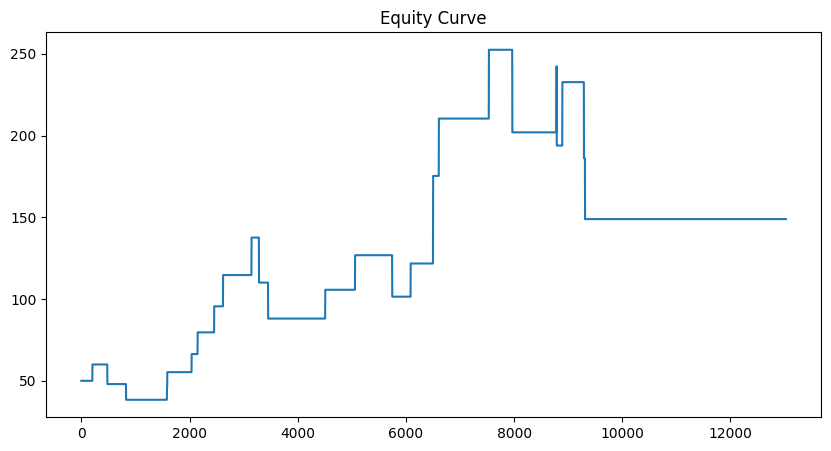

: 

In [ ]:
# ==============================
# Results
# ==============================

trades = np.array(trades)

total = len(trades)
wins = np.sum(trades == 1)
losses = np.sum(trades == -1)

winrate = wins / total if total > 0 else 0

print("Total Trades:", total)
print("Wins:", wins)
print("Losses:", losses)
print("Winrate:", round(winrate*100,2), "%")
print("="*20)
print("Initial Balance", initial_balance)
print("Final Balance:", round(balance,2))

# ==============================
# Equity Curve
# ==============================

plt.figure(figsize=(10,5))
plt.plot(equity)
plt.title("Equity Curve")
plt.show()